# Building a clean cohort

Before any analysis, a cohort has to be defined, checked for implausible values and completed where values are missing.
This tutorial does all of this on the first 48 hours of 11,988 ICU stays of the PhysioNet 2012 challenge {cite}`silva2012predicting` {cite}`goldberger2000physiobank`.
We check data quality and missingness over time, define the cohort by inclusion criteria with a flowchart, handle outliers, impute missing values and describe the final cohort in a "Table 1" by outcome.

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import numpy as np
import pandas as pd

ep.settings.verbosity = "error"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
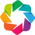

In [3]:
import holoviews as hv

hv.extension("bokeh")

## Data

The PhysioNet 2012 data holds 37 variables recorded hourly, so `.X` has the shape patients × variables × hours.
Static information such as age, sex (`Gender`), ICU type (`ICUType`) and the outcome `In-hospital_death` is in `obs`, and `tem["time_value"]` holds the start of every hour.
We give the outcome readable labels for grouping.

In [4]:
edata = ed.dt.physionet2012()
edata.obs["outcome"] = edata.obs["In-hospital_death"].map({0: "survived", 1: "died"}).astype("category")
edata

EHRData object with n_obs × n_vars × n_t = 11988 × 37 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death', 'outcome'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (11988, 37, 48)

## Quality control

{func}`~ehrapy.preprocessing.qc_metrics` adds missingness and summary statistics of every variable to `var` and of every patient to `obs`.
For 3D data it also measures how variables are measured over time: `measured_obs_pct` is the share of patients with at least one value of a variable, and `median_interval` the median time between two of its values.

In [5]:
ep.pp.qc_metrics(edata, time_key="time_value")
edata.var[["missing_values_pct", "measured_obs_pct", "median_interval", "min", "max"]].sort_values(
    "missing_values_pct"
).round(1)

,missing_values_pct,measured_obs_pct,median_interval,min,max
Parameter,,,,,
HR,9.8,98.6,1.0,0.0,300.0
Urine,30.7,97.5,1.0,0.0,11000.0
SysABP,45.8,70.3,1.0,0.0,285.0
DiasABP,45.8,70.3,1.0,0.0,272.0
MAP,46.1,70.1,1.0,0.0,299.0
Weight,47.3,92.4,1.0,0.0,472.0
NISysABP,57.9,87.7,1.0,0.0,300.0
NIDiasABP,57.9,87.3,1.0,0.0,180.0
NIMAP,58.5,87.3,1.0,0.0,228.0


Vital signs such as heart rate (HR) and blood pressures are recorded every hour, laboratory values roughly every 10 hours.
A missing hour of a vital sign therefore means something different from a missing hour of a lab value, which matters for imputation below.
Some minima and maxima are impossible, such as a temperature of -17.8 °C, a pH of 735 or a weight of 0 kg, which we deal with in the outlier section.

Cholesterol and troponin I are measured in fewer than 10% of patients, too rarely to describe or impute, so we drop them.

In [6]:
edata = edata[:, edata.var["measured_obs_pct"] >= 10].copy()
edata.n_vars

35

On the patient level, `measured_timepoints_pct` is the share of the 48 hours in which a patient has any value, which we use as an inclusion criterion below.

In [7]:
edata.obs[["missing_values_pct", "measured_timepoints_pct", "last_measured_time"]].describe().round(1)

,missing_values_pct,measured_timepoints_pct,last_measured_time
count,11988.0,11988.0,11988.0
mean,79.7,94.1,46.7
std,4.4,12.1,1.8
min,62.6,2.1,1.0
25%,77.2,93.8,47.0
50%,79.6,97.9,47.0
75%,81.9,100.0,47.0
max,99.9,100.0,47.0


### Missing values over time

For 3D data, {func}`~ehrapy.plot.missing_values_matrix` shows the share of observed values of every variable at every hour.

In [8]:
ep.pl.missing_values_matrix(edata, width=800, height=400)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:QuadMesh   [variable,timepoint]   (observed (%))

Heart rate is observed in almost every hour and the blood pressures in about half of them, while lab values are observed in few hours throughout the stay.
Weight is recorded in hour 0 for 92% of patients and in about half of the later hours.

{func}`~ehrapy.plot.missing_values_heatmap` shows which variables are missing together, counting every hour of every patient.

In [9]:
ep.pl.missing_values_heatmap(edata, width=750, height=650)

:HeatMap   [variable,other variable]   (correlation)

Lab values are missing together in blocks, because they are drawn together: the routine blood panel (BUN, creatinine, electrolytes, blood count), the liver panel (ALP, ALT, AST, bilirubin) and the blood gas (PaCO2, PaO2, pH).
Invasive and non-invasive blood pressures are missing in opposite hours, since patients with an arterial line rarely get cuff measurements.
Values that are missing together cannot be predicted from each other, which matters for imputation below.

### Outliers and implausible jumps

{func}`~ehrapy.preprocessing.qc_lab_measurements` flags patients with values outside the normal range of a variable in `obs` (`{var}_outlier`).
For 3D data it also flags implausible changes between two consecutive values (`{var}_jump`).
We set the largest plausible change per hour from clinical knowledge, since the range estimated from the data flags most patients with frequent measurements.

In [10]:
vitals = ["HR", "MAP", "SysABP", "DiasABP", "Temp", "RespRate"]
ep.pp.qc_lab_measurements(
    edata,
    var_names=vitals,
    max_change={"HR": 60, "MAP": 50, "SysABP": 80, "DiasABP": 50, "Temp": 3, "RespRate": 25},
    time_key="time_value",
)
flags = edata.obs.filter(regex="_(outlier|jump)$")
(flags.mean() * 100).round(1).to_frame("patients flagged (%)")

,patients flagged (%)
HR_outlier,11.6
HR_jump,2.6
MAP_outlier,19.1
MAP_jump,10.5
SysABP_outlier,14.7
SysABP_jump,6.4
DiasABP_outlier,19.0
DiasABP_jump,6.1
Temp_outlier,12.8
Temp_jump,1.3


Between 6% and 19% of patients have at least one vital sign outside its normal range, which in the ICU usually reflects illness rather than an error.
Implausible jumps are rarer; those of the invasive blood pressures often come from flushing or moving the arterial line.
We keep these patients and use the flags to inspect them rather than to exclude them.

## Missingness mechanism

Whether imputation can be trusted depends on why values are missing {cite}`rubin1976missingdata`.
{func}`~ehrapy.preprocessing.mcar_test` runs Little's test of whether values are missing completely at random (MCAR).
It works on one timepoint of 3D data, so we test the vital signs at hour 12.

In [11]:
ep.pp.mcar_test(edata[:, vitals, [12]])

4.1051791420328444e-88

:::{important}
The p-value is far below 0.05, so the vital signs are not missing completely at random.
Values that are not MCAR may still be missing at random (MAR), depending only on observed values, which is the assumption all ehrapy imputers make.
No test can tell MAR from missing not at random (MNAR), such as a lab test that was ordered because an abnormal result was suspected, so this assumption has to come from clinical knowledge.
:::

## Cohort definition

We study adult ICU patients without the elective cardiac surgery patients, who were monitored during at least half of the 48 hours and whose heart rate was recorded in the first 6 hours.
{func}`~ehrapy.preprocessing.filter_observations` applies such inclusion criteria as `query` expressions on `obs` columns and variables.
Variables are reduced over the timepoints in `tem_names` with `agg`, and patients for whom a criterion is missing are excluded.
A {class}`~ehrapy.tools.CohortTracker` records every criterion as one step, for a flowchart as proposed by [Ellen et al.](https://www.medrxiv.org/content/10.1101/2023.10.05.23296611v1).

In [12]:
tracker = ep.tl.CohortTracker(
    edata,
    columns=["Age", "Gender", "ICUType", "outcome"],
    categorical=["Gender", "ICUType", "outcome"],
)
tracker(edata, label="ICU stays")
ep.pp.filter_observations(
    edata,
    query=[
        "Age >= 18",
        "ICUType != 'cardiac surgery recovery'",
        "measured_timepoints_pct >= 50",
        "HR > 0",
    ],
    tem_names=slice(0, 6),
    agg="mean",
    tracker=tracker,
)
tracker.plot_flowchart(width=700, height=550)

:Overlay
   .Segments.I   :Segments   [x0,y0,x1,y1]
   .Rectangles.I :Rectangles   [x0,y0,x1,y1]
   .Labels.I     :Labels   [x,y]   (text)
   .Labels.II    :Labels   [x,y]   (text)

The bar plot shows how every step changes the composition of the cohort.

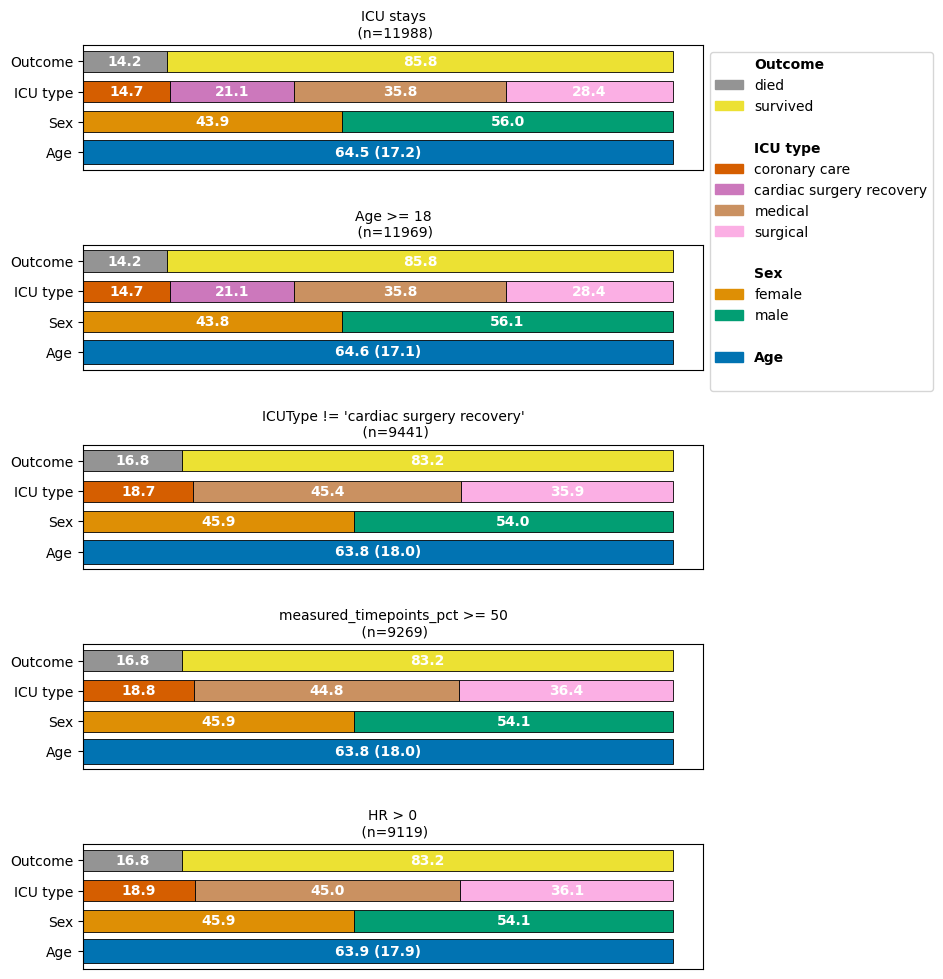

In [13]:
labels = {"Age": "Age", "Gender": "Sex", "ICUType": "ICU type", "outcome": "Outcome"}
fig, axes = tracker.plot_cohort_barplot(
    subfigure_title=True,
    show=False,
    yticks_labels=labels,
    legend_subtitles_names=labels,
    subplots_kwargs={"figsize": (8, 12)},
)
fig.subplots_adjust(hspace=0.6)

Excluding the cardiac surgery recovery unit removes the most patients, and 9,119 of the 11,988 stays remain.
With them, the in-hospital mortality rises from 14.2% to 16.8%, so results on this cohort do not transfer to elective cardiac surgery patients.

## Outliers

The impossible values found above are recording errors, so they become missing values.

In [14]:
plausible = {
    "HR": (1, 300),
    "MAP": (1, 300),
    "SysABP": (1, 300),
    "DiasABP": (1, 300),
    "NIDiasABP": (1, 300),
    "Temp": (25, 45),
    "pH": (6.5, 8),
    "Weight": (20, 300),
}
for var, (low, high) in plausible.items():
    values = edata.X[:, edata.var_names.get_loc(var)]
    values[(values < low) | (values > high)] = np.nan

Extreme but possible values of heavily skewed lab values would dominate means and model fits.
{func}`~ehrapy.preprocessing.winsorize` replaces the largest 1% of every variable by the largest remaining value.

:::{admonition} Missing, clipped or winsorized?
:class: tip
Set impossible values to missing, since clipping them into range invents plausible-looking measurements.
Use {func}`~ehrapy.preprocessing.clip_quantile` with clinical limits when they are known, and {func}`~ehrapy.preprocessing.winsorize` to tame the tails of skewed variables.
:::

In [15]:
skewed = ["ALP", "ALT", "AST", "Bilirubin", "Creatinine", "Glucose", "Lactate", "Platelets", "Urine", "WBC"]
ep.pp.winsorize(edata, var_names=skewed, limits=(0, 0.01))
pd.Series(np.nanmax(edata[:, skewed].X, axis=(0, 2)), index=skewed).round(1)

ALP            703.0
ALT           6460.0
AST           8359.0
Bilirubin       31.9
Creatinine       8.9
Glucose        386.0
Lactate         13.0
Platelets      581.0
Urine          700.0
WBC             40.0
dtype: float64

## Imputation

We impute into a layer, so that `.X` keeps the observed values.
{func}`~ehrapy.preprocessing.locf_impute` carries the last value of the hourly vital signs forward for at most 3 hours, after which the value is too old to stand for the current state.
`MechVent` is only recorded when a patient is ventilated, so a missing value means no ventilation.

In [16]:
edata.layers["imputed"] = edata.X.copy()
hourly = ["HR", "MAP", "SysABP", "DiasABP", "NIMAP", "NISysABP", "NIDiasABP", "Urine"]
ep.pp.locf_impute(edata, var_names=hourly, limit=3, fallback_method=None, layer="imputed")
ep.pp.explicit_impute(edata, replacement={"MechVent": 0}, layer="imputed")

{func}`~ehrapy.preprocessing.gradient_boosting_impute` fills everything else.
It predicts every value from the other variables at the same hour and from the closest values of the same variable before and after it.

In [17]:
ep.pp.gradient_boosting_impute(edata, layer="imputed")

:::{admonition} Which imputer?
:class: tip
Use {func}`~ehrapy.preprocessing.gradient_boosting_impute`, and {func}`~ehrapy.preprocessing.locf_impute` with a `limit` for frequently measured vital signs.
With 10% of the observed hours of all 11,988 PhysioNet 2012 patients hidden, it reached an RMSE of 0.62 on standardized values, compared with 0.82 for `locf_impute` and 0.99 for the mean, in about 40 seconds.
Which imputer works best depends on the data, so on other cohorts it is worth comparing it with alternatives such as `knn_impute` and `miss_forest_impute`, which can do well when variables are strongly related.
:::

:::{seealso}
The [imputation benchmark notebook](https://github.com/theislab/ehrapy-tutorials/blob/main/imputation_nb.ipynb) compares all ehrapy imputers on PhysioNet 2012 in depth, including their runtime and memory use.
:::

:::{warning}
Imputing all patients before a split into training and test patients leaks information from the test patients into the training data.
For prediction, impute within the training patients, as {func}`~ehrapy.ml.fit` does.
:::

Imputed values should not shift the distribution of a variable much.

In [18]:
check = ["HR", "Temp", "GCS", "Lactate"]
pd.DataFrame(
    {
        "observed mean": np.nanmean(edata[:, check].X, axis=(0, 2)),
        "imputed mean": np.nanmean(edata[:, check].layers["imputed"], axis=(0, 2)),
        "observed std": np.nanstd(edata[:, check].X, axis=(0, 2)),
        "imputed std": np.nanstd(edata[:, check].layers["imputed"], axis=(0, 2)),
    },
    index=check,
).round(2)

,observed mean,imputed mean,observed std,imputed std
HR,86.80,86.67,18.71,18.66
Temp,37.06,37.00,0.88,0.76
GCS,11.39,11.68,3.89,3.73
Lactate,2.84,2.01,2.31,1.16


Heart rate, temperature and GCS keep their mean and most of their spread.
Imputed lactate is lower than observed lactate, because lactate is mostly measured when it is suspected to be high.
This is what MAR imputation should do if the other variables explain when lactate is measured, but it cannot be verified, so results that hinge on lactate should be checked on the observed values.

## Table 1

{func}`~ehrapy.tools.stratified_table_one` compares the characteristics of the cohort between patients who survived and who died, with a test per variable.
{func}`~ehrapy.get.obs_df` reads the first observed value of every variable, its baseline, from the observed values in `.X`.

In [19]:
baseline = ["HR", "MAP", "Temp", "GCS", "Lactate", "Creatinine"]
edata.obs[[f"{var} at baseline" for var in baseline]] = ep.get.obs_df(edata, keys=baseline).to_numpy()
ep.tl.stratified_table_one(
    edata,
    "outcome",
    columns=["Age", "Gender", "ICUType", "SAPS-I", "SOFA", *[f"{var} at baseline" for var in baseline]],
    nonnormal=["Lactate at baseline", "Creatinine at baseline"],
)
edata.uns["stratified_table_one"]["table"]

,variable,level,Missing,Overall,died,survived,P-Value
0,n,,,9119,1536,7583,
1,"Age, mean (SD)",,0,63.9 (17.9),69.7 (16.1),62.7 (18.1),<0.001
2,"Gender, n (%)",female,,4183 (45.9),719 (46.8),3464 (45.7),0.711
3,"Gender, n (%)",male,,4929 (54.1),816 (53.1),4113 (54.2),
4,"Gender, n (%)",nan,,7 (0.1),1 (0.1),6 (0.1),
5,"ICUType, n (%)",coronary care,,1719 (18.9),219 (14.3),1500 (19.8),<0.001
6,"ICUType, n (%)",medical,,4105 (45.0),825 (53.7),3280 (43.3),
7,"ICUType, n (%)",surgical,,3295 (36.1),492 (32.0),2803 (37.0),
8,"SAPS-I, mean (SD)",,289,14.3 (5.2),17.5 (5.0),13.7 (5.0),<0.001
9,"SOFA, mean (SD)",,324,6.1 (4.0),8.6 (4.3),5.6 (3.8),<0.001


Patients who died were older, more often treated in the medical ICU and sicker at admission by SAPS-I, SOFA, GCS and lactate, while sex does not differ.
MAP and lactate at baseline are missing for about a third and two fifths of the patients, since invasive MAP needs an arterial line and lactate is not measured in everyone.
Table 1 therefore reports the observed values with their missing counts, not imputed ones.

## Conclusion

The clean cohort holds 9,119 ICU stays without impossible values, with the observed values in `.X` and the imputed ones in the `imputed` layer.
Its flowchart and Table 1 document how it was built and whom it describes, and the quality control flags in `obs` mark the patients worth a closer look.